### FULL CODE, DOWNSAMPLING DATASET + RANDOM FOREST

Cross-Validated F1 Scores: [0.76923077 0.90909091 0.80519481 0.85333333 0.8       ]
Mean F1-Score: 0.8274

Evaluation Metrics:
Accuracy: 0.9000
Precision: 0.9846
Recall: 0.7111
F1-Score: 0.8258
ROC-AUC: 0.9773

Confusion Matrix:
[[179   1]
 [ 26  64]]


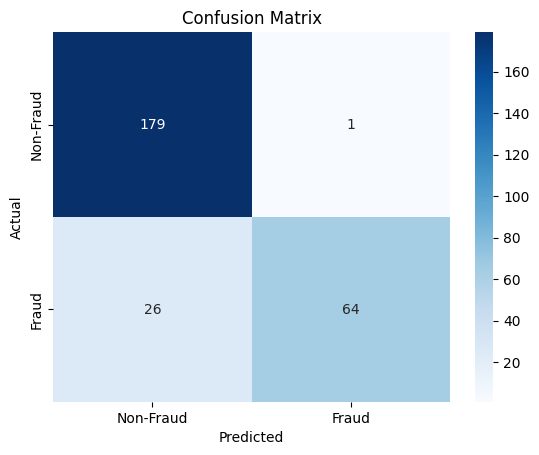

In [53]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
#data = pd.read_csv("gradient_boosting2.csv")

# Define features and target
features = [
    "distance_from_home", "distance_from_last_transaction",
    "ratio_to_median_purchase_price", "repeat_retailer",
    "used_chip", "used_pin_number", "online_order"
]
X = data[features]
y = data["fraud"]

# Handle missing values (if any)
X = X.fillna(X.median())  # Replace NaNs with median

# Further downsample the dataset (reduce it more)
X_downsampled, _, y_downsampled, _ = train_test_split(X, y, test_size=0.85, stratify=y, random_state=42)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_downsampled, y_downsampled, test_size=0.3, stratify=y_downsampled, random_state=42)

# Define Random Forest Classifier with more regularization
rf_classifier = RandomForestClassifier(
    n_estimators=20,  # A few more trees than before
    max_depth=3,  # Slightly deeper trees
    min_samples_split=100,  # Reduced conservative splitting
    min_samples_leaf=50,  # Reduced conservative leaf size
    max_features='sqrt',  # Limit features per split
    random_state=42
)

# Cross-Validation: Use Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compute cross-validated F1 scores
cv_f1_scores = cross_val_score(rf_classifier, X_train, y_train, cv=cv, scoring='f1')
print(f"Cross-Validated F1 Scores: {cv_f1_scores}")
print(f"Mean F1-Score: {cv_f1_scores.mean():.4f}")

# Fit the model
rf_classifier.fit(X_train, y_train)

# Predictions and Probabilities
y_pred = rf_classifier.predict(X_test)
y_proba = rf_classifier.predict_proba(X_test)[:, 1]  # For ROC-AUC

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nEvaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}\n")

# Confusion Matrix
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Non-Fraud", "Fraud"], yticklabels=["Non-Fraud", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()












### CHECKING NUMBER OF RECORDS, 6000 TOTAL

In [58]:
print(data['fraud'].unique())
print(data['fraud'].value_counts())

[0.0, 1.0]
Categories (2, float64): [0.0, 1.0]
fraud
0.0    4000
1.0    2000
Name: count, dtype: int64


### DISTRIBUTION OF RECORDS IN OUR SAMPLED DATASET

<ipython-input-62-728067c9b629>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fraud', data=data, palette='viridis')  # Use 'x' for the column you want to plot


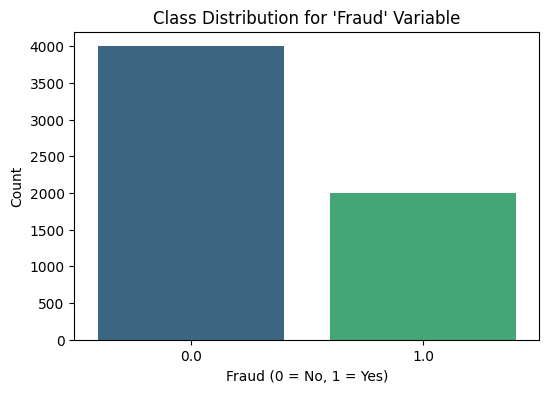

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot class distribution for 'fraud' column
plt.figure(figsize=(6, 4))
sns.countplot(x='fraud', data=data, palette='viridis')  # Use 'x' for the column you want to plot
plt.title("Class Distribution for 'Fraud' Variable")
plt.xlabel("Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()
